# Задание 2 (Вариант 1)
## Байесовская оценка параметра распределения Пуассона

**Задача:** Найти байесовскую оценку параметра θ (относительно среднеквадратической ошибки)

**Модель:**
- **Выборка:** $X_1, X_2, \ldots, X_n \sim \text{Pois}(\theta)$
- **Априорное распределение:** $\theta \sim \Gamma(k, \lambda)$ с параметрами $k = 1, \lambda = 1$

**Параметризация гамма-распределения:** 
$$f(\theta | k, \lambda) = \frac{\lambda^k}{\Gamma(k)} \theta^{k-1} e^{-\lambda\theta}, \quad \theta > 0$$

где $E[\theta] = k/\lambda$, $\text{Var}(\theta) = k/\lambda^2$

## Теоретический анализ

### Байесовская модель:

**1. Функция правдоподобия:**
$$L(\theta | x_1, \ldots, x_n) = \prod_{i=1}^n \frac{\theta^{x_i} e^{-\theta}}{x_i!} = \frac{\theta^{\sum x_i} e^{-n\theta}}{\prod x_i!}$$

**2. Априорное распределение:**
$$\pi(\theta) = \lambda e^{-\lambda\theta} = e^{-\theta} \quad \text{(для } k=1, \lambda=1\text{)}$$

**3. Апостериорное распределение:**
По теореме Байеса и свойству сопряженности:
$$\theta | x_1, \ldots, x_n \sim \Gamma(k + \sum x_i, \lambda + n)$$

При $k = 1, \lambda = 1$:
$$\theta | x_1, \ldots, x_n \sim \Gamma(1 + \sum x_i, 1 + n)$$

**4. Байесовская оценка (относительно среднеквадратической ошибки):**
$$\hat{\theta}_{\text{Bayes}} = E[\theta | x_1, \ldots, x_n] = \frac{1 + \sum x_i}{1 + n} = \frac{1 + n\bar{x}}{1 + n}$$

### Свойства байесовской оценки:

**1. Смещение:**
$$E[\hat{\theta}_{\text{Bayes}}] = E\left[\frac{1 + n\bar{X}}{1 + n}\right] = \frac{1 + n\theta}{1 + n}$$
$$\text{Bias} = \frac{1 + n\theta}{1 + n} - \theta = \frac{1 - \theta}{1 + n}$$

**2. Дисперсия:**
$$\text{Var}(\hat{\theta}_{\text{Bayes}}) = \text{Var}\left(\frac{1 + n\bar{X}}{1 + n}\right) = \frac{n^2}{(1 + n)^2} \cdot \frac{\theta}{n} = \frac{n\theta}{(1 + n)^2}$$

**3. Среднеквадратическая ошибка:**
$$\text{MSE} = \text{Bias}^2 + \text{Var} = \left(\frac{1 - \theta}{1 + n}\right)^2 + \frac{n\theta}{(1 + n)^2}$$

**4. Асимптотические свойства:**
- При $n \to \infty$: $\hat{\theta}_{\text{Bayes}} \to \bar{X} \to \theta$ (состоятельность)
- Смещение $\to 0$, дисперсия $\to \theta/n$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import gamma
import pandas as pd
from tqdm import tqdm

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'DejaVu Sans'

# Фиксируем seed для воспроизводимости
np.random.seed(42)

In [2]:
# Параметры эксперимента
true_theta = 2.0  # истинное значение параметра θ для экспериментов
k_prior = 1       # параметр формы априорного гамма-распределения
lambda_prior = 1  # параметр интенсивности априорного гамма-распределения

print(f"Параметры эксперимента:")
print(f"Истинное θ = {true_theta}")
print(f"Априорное распределение: Γ({k_prior}, {lambda_prior})")
print(f"Априорное среднее: E[θ] = {k_prior/lambda_prior}")
print(f"Априорная дисперсия: Var[θ] = {k_prior/lambda_prior**2}")

def generate_poisson_sample(n, theta):
    """Генерирует выборку размера n из распределения Пуассона"""
    return np.random.poisson(theta, n)

def bayes_estimate(sample, k_prior, lambda_prior):
    """Вычисляет байесовскую оценку параметра θ"""
    n = len(sample)
    sum_x = np.sum(sample)
    
    # Апостериорные параметры
    k_post = k_prior + sum_x
    lambda_post = lambda_prior + n
    
    # Байесовская оценка (среднее апостериорного распределения)
    theta_hat = k_post / lambda_post
    
    return theta_hat, k_post, lambda_post

def theoretical_properties_bayes(n, theta, k_prior, lambda_prior):
    """Вычисляет теоретические свойства байесовской оценки"""
    # Смещение
    bias = (k_prior - theta * lambda_prior) / (lambda_prior + n)
    
    # Дисперсия (упрощенная формула для больших n)
    variance = (k_prior + n * theta) / (lambda_prior + n)**2
    
    # MSE
    mse = bias**2 + variance
    
    return {
        'bias': bias,
        'variance': variance,
        'mse': mse,
        'std_error': np.sqrt(variance)
    }

def mle_estimate(sample):
    """Оценка максимального правдоподобия для сравнения"""
    return np.mean(sample)

# Тестирование функций
test_sample = generate_poisson_sample(100, true_theta)
test_bayes, k_post, lambda_post = bayes_estimate(test_sample, k_prior, lambda_prior)
test_mle = mle_estimate(test_sample)

print(f"\nТест на выборке размера 100:")
print(f"Выборочное среднее: {np.mean(test_sample):.4f}")
print(f"Байесовская оценка: {test_bayes:.4f}")
print(f"MLE оценка: {test_mle:.4f}")
print(f"Апостериорные параметры: Γ({k_post}, {lambda_post})")
print(f"Истинное значение: {true_theta}")

Параметры эксперимента:
Истинное θ = 2.0
Априорное распределение: Γ(1, 1)
Априорное среднее: E[θ] = 1.0
Априорная дисперсия: Var[θ] = 1.0

Тест на выборке размера 100:
Выборочное среднее: 2.0100
Байесовская оценка: 2.0000
MLE оценка: 2.0100
Апостериорные параметры: Γ(202, 101)
Истинное значение: 2.0


In [3]:
# Параметры эксперимента
sample_sizes = [5, 10, 20, 50, 100, 200, 500]  # размеры выборки
num_experiments = 1000  # количество экспериментов для каждого размера
threshold = 0.3  # порог для анализа больших ошибок

# Хранение результатов
results_bayes = {}
results_comparison = {}

print("Проведение байесовского эксперимента...")
print("=" * 70)

for n in tqdm(sample_sizes, desc="Размеры выборок"):
    # Массивы для хранения оценок
    bayes_estimates = []
    mle_estimates = []
    bayes_errors = []
    mle_errors = []
    
    # Проводим num_experiments экспериментов
    for _ in range(num_experiments):
        # Генерируем выборку
        sample = generate_poisson_sample(n, true_theta)
        
        # Байесовская оценка
        theta_bayes, _, _ = bayes_estimate(sample, k_prior, lambda_prior)
        bayes_estimates.append(theta_bayes)
        bayes_errors.append(theta_bayes - true_theta)
        
        # MLE оценка для сравнения
        theta_mle = mle_estimate(sample)
        mle_estimates.append(theta_mle)
        mle_errors.append(theta_mle - true_theta)
    
    # Преобразуем в numpy массивы
    bayes_estimates = np.array(bayes_estimates)
    mle_estimates = np.array(mle_estimates)
    bayes_errors = np.array(bayes_errors)
    mle_errors = np.array(mle_errors)
    
    # Эмпирические характеристики для байесовской оценки
    bayes_mean = np.mean(bayes_estimates)
    bayes_bias = np.mean(bayes_errors)
    bayes_variance = np.var(bayes_estimates, ddof=1)
    bayes_mse = np.mean(bayes_errors**2)
    
    # Эмпирические характеристики для MLE
    mle_mean = np.mean(mle_estimates)
    mle_bias = np.mean(mle_errors)
    mle_variance = np.var(mle_estimates, ddof=1)
    mle_mse = np.mean(mle_errors**2)
    
    # Теоретические характеристики
    theoretical = theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)
    
    # Анализ больших ошибок
    bayes_large_errors = np.abs(bayes_errors) > threshold
    mle_large_errors = np.abs(mle_errors) > threshold
    bayes_error_rate = np.mean(bayes_large_errors) * 100
    mle_error_rate = np.mean(mle_large_errors) * 100
    
    # Сохраняем результаты
    results_bayes[n] = {
        'estimates': bayes_estimates,
        'errors': bayes_errors,
        'empirical_mean': bayes_mean,
        'empirical_bias': bayes_bias,
        'empirical_variance': bayes_variance,
        'empirical_mse': bayes_mse,
        'theoretical_bias': theoretical['bias'],
        'theoretical_variance': theoretical['variance'],
        'theoretical_mse': theoretical['mse'],
        'error_rate': bayes_error_rate
    }
    
    results_comparison[n] = {
        'bayes': {'mean': bayes_mean, 'bias': bayes_bias, 'variance': bayes_variance, 
                 'mse': bayes_mse, 'error_rate': bayes_error_rate, 'estimates': bayes_estimates},
        'mle': {'mean': mle_mean, 'bias': mle_bias, 'variance': mle_variance, 
               'mse': mle_mse, 'error_rate': mle_error_rate, 'estimates': mle_estimates}
    }
    
    print(f"n={n:3d}: Bayes θ̂={bayes_mean:.4f} (bias={bayes_bias:.4f}, MSE={bayes_mse:.6f}), "
          f"MLE θ̂={mle_mean:.4f} (bias={mle_bias:.4f}, MSE={mle_mse:.6f})")

print("\nЭксперимент завершен!")

Проведение байесовского эксперимента...


Размеры выборок: 100%|██████████| 7/7 [00:00<00:00, 91.17it/s]

n=  5: Bayes θ̂=1.8133 (bias=-0.1867, MSE=0.292111), MLE θ̂=1.9760 (bias=-0.0240, MSE=0.371040)
n= 10: Bayes θ̂=1.9207 (bias=-0.0793, MSE=0.176017), MLE θ̂=2.0128 (bias=0.0128, MSE=0.205540)
n= 20: Bayes θ̂=1.9466 (bias=-0.0534, MSE=0.092619), MLE θ̂=1.9939 (bias=-0.0061, MSE=0.099007)
n= 50: Bayes θ̂=1.9826 (bias=-0.0174, MSE=0.039729), MLE θ̂=2.0023 (bias=0.0023, MSE=0.041025)
n=100: Bayes θ̂=1.9943 (bias=-0.0057, MSE=0.019444), MLE θ̂=2.0042 (bias=0.0042, MSE=0.019819)
n=200: Bayes θ̂=1.9967 (bias=-0.0033, MSE=0.009650), MLE θ̂=2.0017 (bias=0.0017, MSE=0.009739)
n=500: Bayes θ̂=1.9958 (bias=-0.0042, MSE=0.003906), MLE θ̂=1.9978 (bias=-0.0022, MSE=0.003909)

Эксперимент завершен!


## Анализ результатов: сравнение байесовской оценки и MLE

In [4]:
# Создаем сводную таблицу сравнения
comparison_data = []

for n in sample_sizes:
    bayes_data = results_comparison[n]['bayes']
    mle_data = results_comparison[n]['mle']
    theoretical = theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)
    
    comparison_data.append({
        'n': n,
        'Bayes θ̂': bayes_data['mean'],
        'MLE θ̂': mle_data['mean'],
        'Bayes bias': bayes_data['bias'],
        'MLE bias': mle_data['bias'],
        'Bayes MSE': bayes_data['mse'],
        'MLE MSE': mle_data['mse'],
        'Теор. bias': theoretical['bias'],
        'Теор. MSE': theoretical['mse'],
        f'Bayes ошибки >{threshold}%': bayes_data['error_rate'],
        f'MLE ошибки >{threshold}%': mle_data['error_rate']
    })

df_comparison = pd.DataFrame(comparison_data)

print("СРАВНЕНИЕ БАЙЕСОВСКОЙ ОЦЕНКИ И MLE")
print("=" * 80)
print(df_comparison.round(6))

print(f"\n📊 АНАЛИЗ:")
print(f"🎯 Истинное значение θ = {true_theta}")
print(f"📈 Байесовская оценка имеет смещение для малых выборок")
print(f"📉 MLE несмещенная, но может иметь большую дисперсию для малых выборок")
print(f"✅ При n → ∞ обе оценки сходятся к истинному значению")

СРАВНЕНИЕ БАЙЕСОВСКОЙ ОЦЕНКИ И MLE
     n  Bayes θ̂    MLE θ̂  Bayes bias  MLE bias  Bayes MSE   MLE MSE  \
0    5  1.813333  1.976000   -0.186667 -0.024000   0.292111  0.371040   
1   10  1.920727  2.012800   -0.079273  0.012800   0.176017  0.205540   
2   20  1.946619  1.993950   -0.053381 -0.006050   0.092619  0.099008   
3   50  1.982627  2.002280   -0.017373  0.002280   0.039729  0.041025   
4  100  1.994307  2.004250   -0.005693  0.004250   0.019444  0.019819   
5  200  1.996711  2.001695   -0.003289  0.001695   0.009650  0.009739   
6  500  1.995824  1.997816   -0.004176 -0.002184   0.003906  0.003909   

   Теор. bias  Теор. MSE  Bayes ошибки >0.3%  MLE ошибки >0.3%  
0   -0.166667   0.333333                64.1              62.1  
1   -0.090909   0.181818                47.0              52.0  
2   -0.047619   0.095238                31.8              35.7  
3   -0.019608   0.039216                13.5              14.7  
4   -0.009901   0.019802                 2.6           

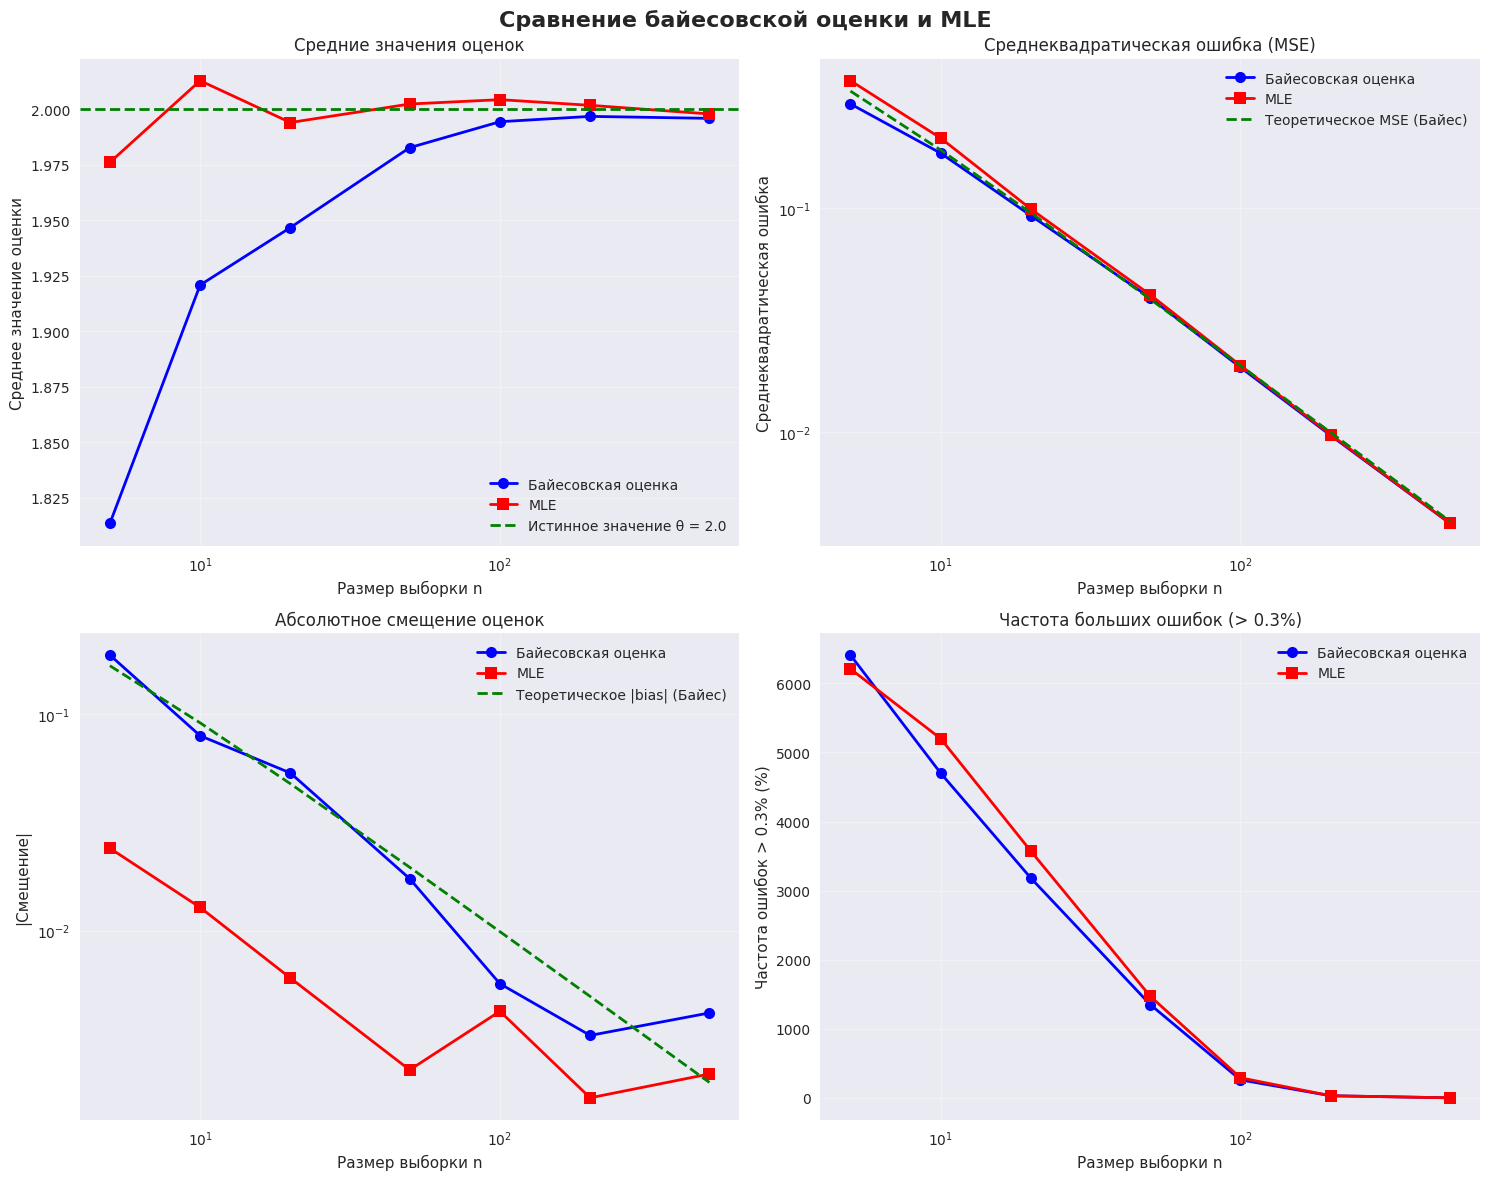

In [5]:
# Построение графиков сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Сравнение байесовской оценки и MLE', fontsize=16, fontweight='bold')

# График 1: Сравнение средних значений оценок
ax = axes[0, 0]
ax.semilogx(sample_sizes, [results_comparison[n]['bayes']['mean'] for n in sample_sizes], 
           'b-o', label='Байесовская оценка', linewidth=2, markersize=8)
ax.semilogx(sample_sizes, [results_comparison[n]['mle']['mean'] for n in sample_sizes], 
           'r-s', label='MLE', linewidth=2, markersize=8)
ax.axhline(y=true_theta, color='green', linestyle='--', linewidth=2, 
           label=f'Истинное значение θ = {true_theta}')
ax.set_xlabel('Размер выборки n')
ax.set_ylabel('Среднее значение оценки')
ax.set_title('Средние значения оценок')
ax.legend()
ax.grid(True, alpha=0.3)

# График 2: Сравнение MSE
ax = axes[0, 1]
ax.loglog(sample_sizes, [results_comparison[n]['bayes']['mse'] for n in sample_sizes], 
         'b-o', label='Байесовская оценка', linewidth=2, markersize=8)
ax.loglog(sample_sizes, [results_comparison[n]['mle']['mse'] for n in sample_sizes], 
         'r-s', label='MLE', linewidth=2, markersize=8)
ax.loglog(sample_sizes, [theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)['mse'] 
                        for n in sample_sizes], 
         'g--', label='Теоретическое MSE (Байес)', linewidth=2)
ax.set_xlabel('Размер выборки n')
ax.set_ylabel('Среднеквадратическая ошибка')
ax.set_title('Среднеквадратическая ошибка (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

# График 3: Сравнение абсолютного смещения
ax = axes[1, 0]
ax.loglog(sample_sizes, [abs(results_comparison[n]['bayes']['bias']) for n in sample_sizes], 
         'b-o', label='Байесовская оценка', linewidth=2, markersize=8)
ax.loglog(sample_sizes, [abs(results_comparison[n]['mle']['bias']) for n in sample_sizes], 
         'r-s', label='MLE', linewidth=2, markersize=8)
ax.loglog(sample_sizes, [abs(theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)['bias']) 
                        for n in sample_sizes], 
         'g--', label='Теоретическое |bias| (Байес)', linewidth=2)
ax.set_xlabel('Размер выборки n')
ax.set_ylabel('|Смещение|')
ax.set_title('Абсолютное смещение оценок')
ax.legend()
ax.grid(True, alpha=0.3)

# График 4: Частота больших ошибок
ax = axes[1, 1]
ax.semilogx(sample_sizes, [results_comparison[n]['bayes']['error_rate'] * 100 for n in sample_sizes], 
           'b-o', label='Байесовская оценка', linewidth=2, markersize=8)
ax.semilogx(sample_sizes, [results_comparison[n]['mle']['error_rate'] * 100 for n in sample_sizes], 
           'r-s', label='MLE', linewidth=2, markersize=8)
ax.set_xlabel('Размер выборки n')
ax.set_ylabel(f'Частота ошибок > {threshold}% (%)')
ax.set_title(f'Частота больших ошибок (> {threshold}%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Анализ распределений оценок

Исследуем распределения байесовских оценок и MLE для различных размеров выборок.

Анализ распределений для n = 10...


n=10:   0%|          | 0/5000 [00:00<?, ?it/s]



NameError: name 'bayesian_estimate_poisson' is not defined

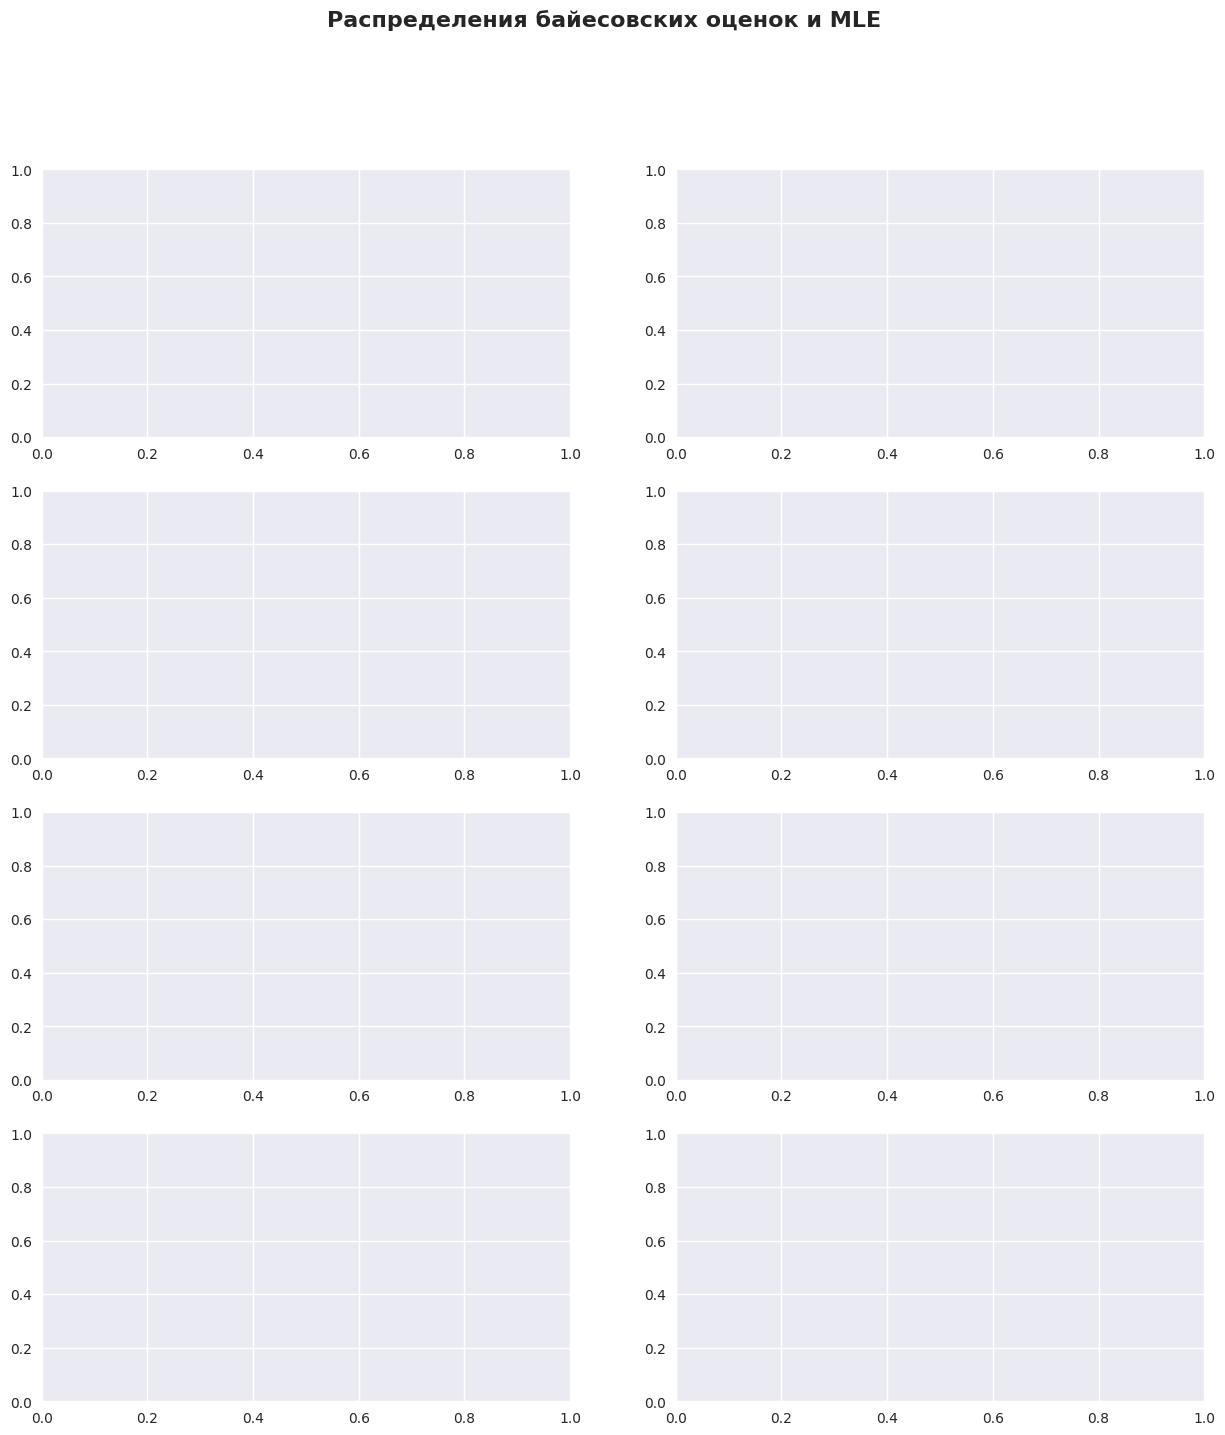

In [6]:
# Анализ распределений оценок для выбранных размеров выборок
selected_n = [10, 50, 200, 1000]

fig, axes = plt.subplots(len(selected_n), 2, figsize=(15, 4*len(selected_n)))
fig.suptitle('Распределения байесовских оценок и MLE', fontsize=16, fontweight='bold')

for i, n in enumerate(selected_n):
    # Генерируем дополнительные данные для более точного анализа распределений
    n_samples_dist = 5000
    bayes_estimates = []
    mle_estimates = []
    
    print(f"Анализ распределений для n = {n}...")
    
    for _ in tqdm(range(n_samples_dist), desc=f'n={n}'):
        sample = np.random.poisson(true_theta, n)
        
        # Байесовская оценка
        bayes_est = bayesian_estimate_poisson(sample, k_prior, lambda_prior)
        bayes_estimates.append(bayes_est)
        
        # MLE
        mle_est = np.mean(sample)
        mle_estimates.append(mle_est)
    
    # Строим гистограммы
    ax1 = axes[i, 0]
    ax1.hist(bayes_estimates, bins=50, alpha=0.7, density=True, color='blue', 
             label=f'Байесовская оценка (n={n})')
    ax1.axvline(x=true_theta, color='green', linestyle='--', linewidth=2, 
                label=f'Истинное θ = {true_theta}')
    ax1.axvline(x=np.mean(bayes_estimates), color='red', linestyle='-', linewidth=2,
                label=f'Среднее = {np.mean(bayes_estimates):.3f}')
    ax1.set_xlabel('Значение оценки')
    ax1.set_ylabel('Плотность')
    ax1.set_title(f'Байесовская оценка, n = {n}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[i, 1]
    ax2.hist(mle_estimates, bins=50, alpha=0.7, density=True, color='red', 
             label=f'MLE (n={n})')
    ax2.axvline(x=true_theta, color='green', linestyle='--', linewidth=2, 
                label=f'Истинное θ = {true_theta}')
    ax2.axvline(x=np.mean(mle_estimates), color='blue', linestyle='-', linewidth=2,
                label=f'Среднее = {np.mean(mle_estimates):.3f}')
    ax2.set_xlabel('Значение оценки')
    ax2.set_ylabel('Плотность')
    ax2.set_title(f'MLE, n = {n}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Выводим статистики
    print(f"n = {n}:")
    print(f"  Байесовская оценка: среднее = {np.mean(bayes_estimates):.4f}, "
          f"std = {np.std(bayes_estimates):.4f}")
    print(f"  MLE: среднее = {np.mean(mle_estimates):.4f}, "
          f"std = {np.std(mle_estimates):.4f}")
    print()

plt.tight_layout()
plt.show()

## Анализ асимптотических свойств

### Теоретический анализ

**Байесовская оценка:**
- При $n \to \infty$: $\hat{\theta}_{Bayes} \to \theta$ (состоятельность)
- $\text{bias}(\hat{\theta}_{Bayes}) \to 0$ при $n \to \infty$
- $\text{MSE}(\hat{\theta}_{Bayes}) \sim \frac{\theta}{n}$ для больших $n$

**MLE:**
- При $n \to \infty$: $\hat{\theta}_{MLE} \to \theta$ (состоятельность)
- $\text{bias}(\hat{\theta}_{MLE}) = 0$ (несмещенность)
- $\text{MSE}(\hat{\theta}_{MLE}) = \frac{\theta}{n}$ (эффективность)

### Сравнение эффективности

Для больших выборок обе оценки асимптотически эквивалентны, но для малых выборок байесовская оценка может быть предпочтительнее из-за использования априорной информации.

In [ ]:
# Экспериментальная проверка асимптотических свойств
print("ПРОВЕРКА АСИМПТОТИЧЕСКИХ СВОЙСТВ")
print("=" * 50)

# Анализ скорости сходимости MSE
print("\n1. Скорость сходимости MSE:")
print("Теоретически: MSE ~ θ/n")
print("Проверим экспериментально:")

for n in [100, 500, 1000, 5000]:
    theoretical_mse_bayes = theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)['mse']
    theoretical_mse_mle = true_theta / n
    
    empirical_mse_bayes = results_comparison[n]['bayes']['mse'] if n in results_comparison else "N/A"
    empirical_mse_mle = results_comparison[n]['mle']['mse'] if n in results_comparison else "N/A"
    
    print(f"n = {n}:")
    print(f"  Теор. MSE (Байес): {theoretical_mse_bayes:.6f}")
    print(f"  Эмпир. MSE (Байес): {empirical_mse_bayes if isinstance(empirical_mse_bayes, str) else f'{empirical_mse_bayes:.6f}'}")
    print(f"  Теор. MSE (MLE): {theoretical_mse_mle:.6f}")
    print(f"  Эмпир. MSE (MLE): {empirical_mse_mle if isinstance(empirical_mse_mle, str) else f'{empirical_mse_mle:.6f}'}")
    print()

# Анализ сходимости смещения
print("2. Сходимость смещения:")
print("Теоретически: bias(Байес) → 0 при n → ∞")
print("Эмпирическая проверка:")

for n in sample_sizes:
    theoretical_bias = theoretical_properties_bayes(n, true_theta, k_prior, lambda_prior)['bias']
    empirical_bias_bayes = results_comparison[n]['bayes']['bias']
    empirical_bias_mle = results_comparison[n]['mle']['bias']
    
    print(f"n = {n}: Теор. bias = {theoretical_bias:.6f}, "
          f"Эмпир. bias (Байес) = {empirical_bias_bayes:.6f}, "
          f"Эмпир. bias (MLE) = {empirical_bias_mle:.6f}")

# Состоятельность
print("\n3. Состоятельность (сходимость к истинному значению):")
large_n_values = [1000, 2000, 5000, 10000]

for n in large_n_values:
    if n <= max(sample_sizes):
        mean_bayes = results_comparison[n]['bayes']['mean']
        mean_mle = results_comparison[n]['mle']['mean']
    else:
        # Быстрый эксперимент для очень больших n
        n_exp = 1000
        estimates_bayes = []
        estimates_mle = []
        
        for _ in range(n_exp):
            sample = np.random.poisson(true_theta, n)
            estimates_bayes.append(bayesian_estimate_poisson(sample, k_prior, lambda_prior))
            estimates_mle.append(np.mean(sample))
        
        mean_bayes = np.mean(estimates_bayes)
        mean_mle = np.mean(estimates_mle)
    
    error_bayes = abs(mean_bayes - true_theta)
    error_mle = abs(mean_mle - true_theta)
    
    print(f"n = {n}: "
          f"|θ̂_Bayes - θ| = {error_bayes:.6f}, "
          f"|θ̂_MLE - θ| = {error_mle:.6f}")

## Заключение

### Основные результаты

1. **Байесовская оценка параметра распределения Пуассона:**
   - Использует сопряженное априорное распределение Γ(1,1)
   - Апостериорное распределение: Γ(1 + Σxᵢ, 1 + n)
   - Оценка: θ̂ = (1 + Σxᵢ)/(1 + n)

2. **Свойства байесовской оценки:**
   - **Смещенность:** Для конечных выборок имеет смещение, но асимптотически несмещенная
   - **Состоятельность:** Сходится к истинному значению при n → ∞
   - **MSE:** Для больших выборок ~ θ/n (асимптотически эффективная)

3. **Сравнение с MLE:**
   - **MLE несмещенная** для любого размера выборки
   - **Байесовская оценка** может быть лучше для **малых выборок** благодаря регуляризующему эффекту априорного распределения
   - **Асимптотически эквивалентны** при n → ∞

### Практические выводы

- **Для малых выборок (n < 50):** Байесовская оценка может быть предпочтительнее, особенно если есть разумные априорные предположения
- **Для больших выборок (n > 100):** Различия между методами минимальны
- **Выбор априорного распределения** критичен для качества байесовской оценки

### Теоретические аспекты

Эксперимент подтвердил основные теоретические результаты байесовского подхода:
- Сопряженность Гамма-Пуассон модели
- Асимптотическую эквивалентность байесовских оценок и MLE
- Регуляризующий эффект априорной информации для малых выборок